# Example Problem for Machine Learning 01 - Simple Linear Regression

This is one of the most basic machine learning problems:  
Given input and output, try to find the slope and offset of a line ($ y = a x + b $) via [simple linear regression](https://en.wikipedia.org/wiki/Linear_regression#Simple_and_multiple_linear_regression).

REF: This article contains some content from [TensorFlow basics/Basic training loops](https://www.tensorflow.org/guide/basic_training_loops).

## 1. TensorFlow official guide

In the TensorFlow official guides, we have learned about 
[tensors](https://www.tensorflow.org/guide/tensor), 
[variables](https://www.tensorflow.org/guide/variable), 
[gradient tape](https://www.tensorflow.org/guide/autodiff), and 
[modules](https://www.tensorflow.org/guide/intro_to_modules). 
In this guide, we will fit these all together to train models.

## 2. Setup

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

2026-04-19 13:50:52.634149: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-19 13:50:53.203365: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776577853.428245    3020 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776577853.483742    3020 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776577853.954506    3020 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 3. Procedure of solving machine learning problems

Solving a machine learning problem usually consists of the following steps:

1. Obtain training data.
2. Define the model.
3. Define a loss function.
4. Run through the training data, calculating loss from the ideal value.
5. Calculate gradients for that loss and use an *optimizer* to adjust the variables to fit the data.
6. Evaluate the results.

## 4. Example Problem: Simple Linear Regression

This is one of the most basic machine learning problems: Given $x$ (input) and $y$ (output), try to find the slope and offset of a line via [simple linear regression](https://en.wikipedia.org/wiki/Linear_regression#Simple_and_multiple_linear_regression).

For illustration purposes, in this guide, we'll develop a simple linear model,  

$$f(x) = x \times W + b ,$$

which has two variables: $W$ (weights) and $b$ (bias).

## 5. Data

**Desription:**  
"[Supervised learning (SL)](https://en.wikipedia.org/wiki/Supervised_learning)" is a type of machine learning paradigm where an algorithm learns to map input data to a specific output based on example `input-output pairs`. In other words, SL uses *inputs* (usually denoted as *x*) and *outputs* (denoted *y*, often called *labels*). The goal is to learn from paired inputs and outputs so that we can predict the value of an output from an input.

Each input of our data, in TensorFlow, is almost always represented by a tensor, and is often a vector. In supervised training, the output (or value we'd like to predict) is also a tensor.

|        | Usually denoted | Often called | In TensorFlow |
| ------ | --------------- | ------------ | ------------- |
| Input  | *x*             |              | `tf.tensor`   |
| Output | *y* or *f(x)*   | *labels*     | `tf.tensor`   |

**Example: Data creation**  
Here is some data synthesized by adding Gaussian (normal) noise to points along the line.

In [2]:
# Create an actual line: f_TRUE(x) = x * TRUE_W + TRUE_b

# Set line factors
TRUE_W = 3.0        # Slope
TRUE_b = 2.0        # Offset
NUM_SAMPLES = 201   # Number of sample points

# A vector of x values within a specific range
x = tf.linspace(-2.0, 2.0, NUM_SAMPLES)   # A vector (rank-1 `tf.Tensor`) from -2 to 2, dtype=float64

x = tf.cast(x, tf.float32)            # Convert a tensor from `tf.float64` to `tf.float32`
                                      # In this example, we don't need very high precision. 
                                      # Meanwhile, we can save computational resources.

# Define the function of actual line
def f_TRUE(x):
    return x * TRUE_W + TRUE_b

# Generate some noise (random values from a normal distribution).
sigma_value = 1.0  # Set the standard deviation (sigma value) of the normal distribution
noise = tf.random.normal(shape=[NUM_SAMPLES], stddev=sigma_value)  # Default setting: stddev=1.0

# Calculate the data y_data = the actual line + noise
y_data = f_TRUE(x) + noise

I0000 00:00:1776577937.908488    3020 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


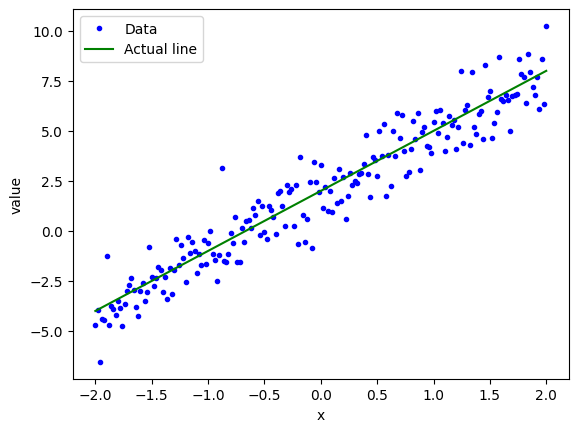

In [3]:
# Plot all the data and the actual line
plt.plot(x,    y_data,  ".", color="b", label="Data")
plt.plot(x, f_TRUE(x),       color="g", label="Actual line")
plt.xlabel("x")
plt.ylabel("value")
plt.legend()
plt.show()

Tensors are usually gathered together in *batches*, or groups of inputs and outputs stacked together. Batching can confer some training benefits and works well with accelerators and vectorized computation. 

Since this dataset is small, we can treat the entire dataset as a single batch, i.e., `batch processing` in `full batch mode` with $B = N_{dataset}$, , where $N_{dataset}$ is the number of samples of the entire dataset (or say "one complete pass of the entire training dataset"). This indicates that the model processes the entire dataset at once before updating its internal parameters (weights).

REF: [Epoch, Batch, Batch Size, Weight Update, and Iteration](https://github.com/HsienChing/ML_DL_project_State_Estimation_of_Li-ion_Batteries/blob/main/supplementary_materials/Epoch_Batch_Iteration.ipynb)

## 6. Define a model

**Description:**  
Use [`tf.Variable`](https://www.tensorflow.org/api_docs/python/tf/Variable) to represent all weights in a model. A [`tf.Variable`](https://www.tensorflow.org/api_docs/python/tf/Variable) stores a value and provides this in tensor form as needed. See the [variable guide](https://www.tensorflow.org/guide/variable) for more details.

Use [`tf.Module`](https://www.tensorflow.org/api_docs/python/tf/Module) to encapsulate the variables and the computation. We could use any Python object, but this way it can be easily saved.

**Example: Define the model**  
Here, we define both *W* and *b* as `tf.Variables`.

In [4]:
class MyModel(tf.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        # Initialize the weights (slope) to `5.0` and the bias to `0.0`
        # In practice, these should be randomly initialized
        self.W = tf.Variable(5.0)
        self.b = tf.Variable(0.0)

    def __call__(self, x):
        return x * self.W + self.b

model = MyModel()

# List the variables `tf.modules`'s built-in varialbe aggregation.
print("Variables:", model.variables)

# Verify and check the model works
# If works, a value of `x * self.W + self.b` should be returned.
assert model(3.0).numpy() == 15.0

Variables: (<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=5.0>, <tf.Variable 'Variable:0' shape=() dtype=float32, numpy=0.0>)


The initial variables are set here in a fixed way, but Keras comes with any of a number of [initializers](https://www.tensorflow.org/api_docs/python/tf/keras/initializers) you could use, with or without the rest of Keras.

## 7. Define a loss function

**Description:**  
A loss function measures how well the output of a model for a given input matches the target output. The goal is to minimize this difference during training. 

**Example: Define a loss function**  
Define the standard $L_2$ loss, also known as the "mean square error".

**$L_1$ Loss Function**  
$L_1$ Loss Function is used to minimize the error, which is the sum of all the **absolute** differences (distances) between the true value and the predicted value.

$$ \mathrm{L_1 Loss Function} = \sum_{i=1}^n |y_{predicted} - y_{true}|$$

**Mean Absolute Error (MAE)**

$$ MAE = \frac{1}{n} \sum_{i=1}^n |y_{predicted} - y_{true}| $$

**$L_2$ Loss Function**  
$L_2$ Loss Function is used to minimize the error, which is the sum of all the **squared** differences (distances) between the true value and the predicted value.

$$ \mathrm{L_2 Loss Function} = \sum_{i=1}^n (y_{predicted} - y_{true})^2$$

**Mean Square Error (MSE)**

$$ MSE = \frac{1}{n} \sum_{i=1}^n (y_{predicted} - y_{true})^2 $$

**Related `TensorFlow` API:**  
[`tf.reduce_mean`](https://www.tensorflow.org/api_docs/python/tf/math/reduce_mean)  
Computes the mean of elements across dimensions of a tensor.

[`tf.square`](https://www.tensorflow.org/api_docs/python/tf/math/square)  
Computes the square of x element-wise.



In [5]:
# This computes a single loss value (MSE) for an entire batch
def loss(y_predicted, y_data):
    return tf.reduce_mean(tf.square(y_predicted - y_data))  # Calculate MSE

Before training the model, we can visualize the deviation by plotting the model's initial predictions in red line and the training data in blue points:

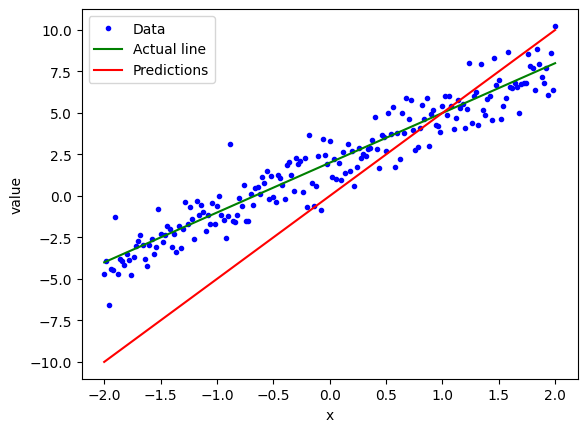

Current loss (MSE): 10.058792


In [6]:
plt.plot(x,    y_data, ".", color="b", label="Data")
plt.plot(x, f_TRUE(x),      color="g", label="Actual line")
plt.plot(x,  model(x),      color="r", label="Predictions")
plt.legend()
plt.xlabel("x")
plt.ylabel("value")
plt.show()

print("Current loss (MSE):", loss(model(x), y_data).numpy())

It's obvious that the predicted line before training (red line) is far from the data points (blue dots).

## 8. Define a training loop

**Description:**  
The training loop consists of repeatedly doing three tasks in order:

- Sending a `batch` of inputs through the model to generate outputs
- Calculating the `loss` by comparing the outputs to the output (or *label*)
- Using `gradient tape` to find the `gradients`
- Optimizing the `variables` with those `gradients`

**Example: Define a training loop**  
For this example, we can train the model using [gradient descent](https://en.wikipedia.org/wiki/Gradient_descent).

There are many variants of the gradient descent scheme that are captured in [`tf.keras.optimizers`](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers). But in the spirit of building from first principles, here we will implement the basic math ourselves with the help of [`tf.GradientTape`](https://www.tensorflow.org/api_docs/python/tf/GradientTape) for automatic differentiation and `tf.assign_sub` for decrementing a value (which combines `tf.assign` and `tf.sub`):

**Note:**  
Use `assign_add` and `assign_sub` to avoid `tf.Variable` becomes `tf.Tensor`. One common error is to inadvertently replace a [`tf.Variable`](https://www.tensorflow.org/api_docs/python/tf/Variable) with a [`tf.Tensor`](https://www.tensorflow.org/api_docs/python/tf/Tensor), instead of using [`Variable.assign`](https://www.tensorflow.org/api_docs/python/tf/Variable#assign) to update the [`tf.Variable`](https://www.tensorflow.org/api_docs/python/tf/Variable). (see [Replaced a variable with a tensor](https://www.tensorflow.org/guide/autodiff#1_replaced_a_variable_with_a_tensor))


In [7]:
# Given a callable model, inputs, outputs, and a learning rate...
def train(model, x, y_data, learning_rate):

    with tf.GradientTape() as tape:
        # Trainable variables are automatically tracked by GradientTape
        current_loss = loss(model(x), y_data)

    # Use GradientTape to calculate the gradients with respect to W and b
    dloss_dW, dloss_db = tape.gradient(current_loss, [model.W, model.b])    #  dy/dx = tape.gradient(y, x)

    # Update internal parameters (weights)
    # Substract the gradient scaled by the learning rate
    model.W.assign_sub(learning_rate * dloss_dW)
    model.b.assign_sub(learning_rate * dloss_db)

For a look at training, we can send the same batch of *x* and *y_data* through the training loop, and see how *W* and *b* evolve.

In [8]:
# Select the model
model = MyModel()

# Collect the history of W, b, and loss values to plot later
weights = []
biases  = []
losses  = []
num_epochs  = range(10)   # Set the number of epoch

# Define a `report` function
def report(model, loss):
    return f"W = {model.W.numpy():1.2f}, b = {model.b.numpy():1.2f}, loss = {loss:2.5f}"

# Define a `training loop` function
def training_loop(model, x, y_data):
    for epoch in num_epochs:
        # Update the model with the single batch
        train(model, x, y_data, learning_rate=0.1)

        # Track this before iteration update
        current_loss = loss(model(x), y_data)
        weights.append(model.W.numpy())  # Use append() to add the element to the end of the list
        biases.append(model.b.numpy())
        losses.append(current_loss.numpy())

        print("Epoch:", epoch)
        print("    ", report(model, current_loss))

Execute the training and display the internal parameters

In [9]:
# Get the initialized values
current_loss = loss(model(x), y_data)

print("Starting (initialized values):")
print("    ", report(model, current_loss))

# Execute training loop
training_loop(model, x, y_data)

Starting (initialized values):
     W = 5.00, b = 0.00, loss = 10.05879
Epoch: 0
     W = 4.46, b = 0.38, loss = 6.25299
Epoch: 1
     W = 4.07, b = 0.68, loss = 4.08449
Epoch: 2
     W = 3.78, b = 0.92, loss = 2.83930
Epoch: 3
     W = 3.57, b = 1.12, loss = 2.11855
Epoch: 4
     W = 3.41, b = 1.27, loss = 1.69792
Epoch: 5
     W = 3.30, b = 1.40, loss = 1.45043
Epoch: 6
     W = 3.22, b = 1.49, loss = 1.30362
Epoch: 7
     W = 3.16, b = 1.57, loss = 1.21586
Epoch: 8
     W = 3.12, b = 1.64, loss = 1.16299
Epoch: 9
     W = 3.08, b = 1.69, loss = 1.13091


Plot the evolution of the weight and bias as the epoch increases:

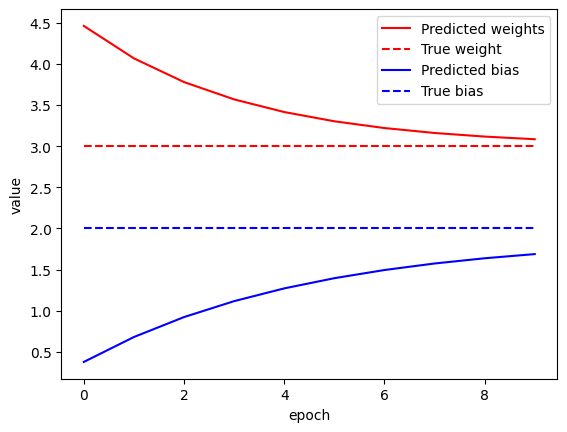

In [10]:
plt.plot(num_epochs, weights, color="r", label="Predicted weights")
plt.plot(num_epochs, [TRUE_W] * len(num_epochs), "--",
         color="r", label="True weight")

plt.plot(num_epochs, biases,  color="b", label="Predicted bias")
plt.plot(num_epochs, [TRUE_b] * len(num_epochs), "--",
         color="b", label="True bias")

plt.legend()
plt.xlabel("epoch")
plt.ylabel("value")
plt.show()

As the epoch increases, the values of predicted weight and bias are close to the values of true weight and bias.


The evolution of MSE vs. epoch:

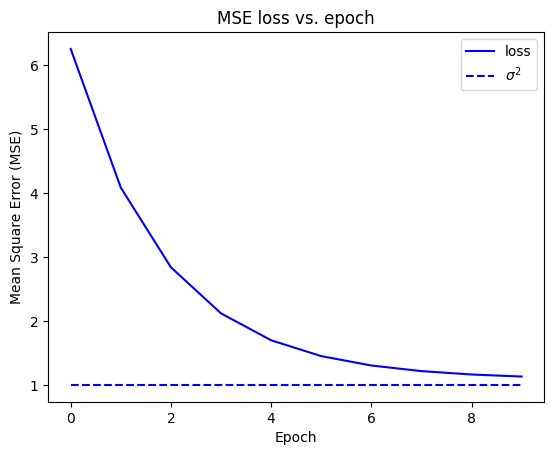

In [11]:
plt.plot(num_epochs, losses, color="b", label="loss")
plt.plot(num_epochs, [sigma_value**2] * len(num_epochs), "--",
         color="b", label="$\\sigma^2$")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Mean Square Error (MSE)")
plt.title('MSE loss vs. epoch')
plt.show()

As the epoch increases, the loss is close to 1.

## 9. Evaluate the results

Visualize how the trained model performs:

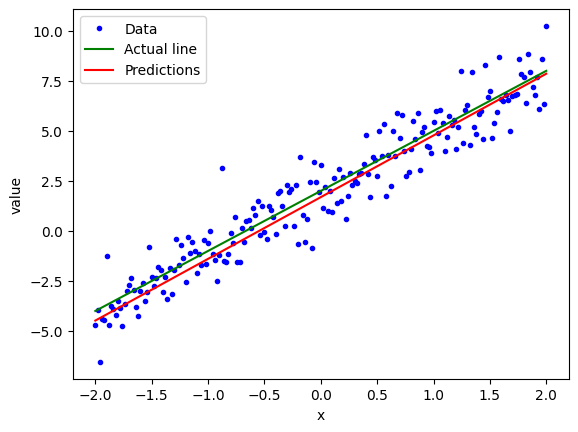

Current loss: 1.130915


In [12]:
plt.plot(x,    y_data, ".", color="b", label="Data")
plt.plot(x, f_TRUE(x),      color="g", label="Actual line")
plt.plot(x,  model(x),      color="r", label="Predictions")
plt.legend()
plt.xlabel("x")
plt.ylabel("value")
plt.show()

print("Current loss: %1.6f" % loss(model(x), y_data).numpy())

The predicted line after training (red line) is close to the data points (blue dots) and the actual line (green line).

## 10. About the normal distribution noise

In the abovementioned example, we use [`tf.random.normal`](https://www.tensorflow.org/api_docs/python/tf/random/normal), random values from a normal distribution, to generate the data noise. 
```python
# Generate some noise (random values from a normal distribution).
noise = tf.random.normal(shape=[NUM_SAMPLES])

# Calculate the data y_data = the actual line + noise
y_data = f_TRUE(x) + noise
```

We should discuss something about the noise. 

**Observation:**

1. In the code (`tf.random.normal(shape=[Num_data_points])`), an argument `stddev` with the default value `1.0` is hidden.
2. The corresponding `loss` is ~ 1.

**Test:**

As we set the `stddev`=$n$, we will see that the loss is ~ $n^2$.  

For example:
When `stddev=3.0`, the correspondiing loss is ~ 9
```python
noise = tf.random.normal(shape=[NUM_SAMPLES], stddev=3.0)
```

A table is given below for reference.

| Stddev of noise   | Loss (MSE) |
| ----------------- | ---------: |
| 1 (Default value) |         ~1 | 
| 2                 |        ~ 4 | 
| 3                 |        ~ 9 |
| 4                 |       ~ 16 |

Note: To get the approaching loss value, we should set larger calculation parameters, such as `NUM_SAMPLES = 20001`, `epoch = 20`.

**Theoretical explanation:**

1. Standard deviation in a normal distribution

In a normal distribution, the standard deviation ($\sigma$ or $s$) is a statistical measure of how dispersed or spread out data points are around their mean (average). A small value of standard deviation means data clusters closely around the mean, while a large value of standard deviation indicates data is spread over a wider range. It is the square root of the variance. 

The definition of the standard deviation is 
$$ \sigma = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu )^2 } , $$
where $\mu$ indicates the mean value.

2. Mean Square Error (MSE)

$$ MSE = \frac{1}{n} \sum_{i=1}^n (y_{predicted} - y_{true})^2 $$

3. Compare equations:

When we compare the above two equations, it's obvious to find out that $\sigma ^2$ = MSE. 

**Conclusion:**  
As we produce the `y_data` with normal distribution noise (of $\sigma = n$) and use a linear model for training, the value of loss will be close to $n^2$.